In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [19]:
df = pd.read_csv("diabetes.csv")

In [20]:
df['Insulin'].replace(0, np.nan, inplace=True)
df['SkinThickness'].replace(0, np.nan, inplace=True)

<ipython-input-20-48eca6f995e3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Insulin'].replace(0, np.nan, inplace=True)
<ipython-input-20-48eca6f995e3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [21]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,NaN,33.6,0.627,50,1
1,1,85,66,29.0,NaN,26.6,0.351,31,0
2,8,183,64,NaN,NaN,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0
764,2,122,70,27.0,NaN,36.8,0.340,27,0
765,5,121,72,23.0,112.0,26.2,0.245,30,0
766,1,126,60,NaN,NaN,30.1,0.349,47,1


In [22]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['Insulin'] = imputer.fit_transform(df[['Insulin']])
df['SkinThickness'] = imputer.fit_transform(df[['SkinThickness']])
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.00000,155.548223,33.6,0.627,50,1
1,1,85,66,29.00000,155.548223,26.6,0.351,31,0
2,8,183,64,29.15342,155.548223,23.3,0.672,32,1
3,1,89,66,23.00000,94.000000,28.1,0.167,21,0
4,0,137,40,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.00000,180.000000,32.9,0.171,63,0
764,2,122,70,27.00000,155.548223,36.8,0.340,27,0
765,5,121,72,23.00000,112.000000,26.2,0.245,30,0
766,1,126,60,29.15342,155.548223,30.1,0.349,47,1


In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [24]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(max_iter=1000)
model_LR.fit(X_train, y_train)

y_pred_LR = model_LR.predict(X_test)

y_proba_LR = model_LR.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier()
model_DT.fit(X_train, y_train)

y_pred_DT = model_DT.predict(X_test)

y_proba_DT = model_DT.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier()
model_RF.fit(X_train, y_train)

y_pred_RF = model_RF.predict(X_test)

y_proba_RF = model_RF.predict_proba(X_test)[:, 1]

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
def evaluate(y_pred):
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average=None)
  recall = recall_score(y_test, y_pred, average=None)
  f1 = f1_score(y_test, y_pred, average=None)

  print(f'Accuracy \t= {accuracy} \nPrecision \t= {precision} \nRecall \t\t= {recall} \nf1 score \t= {f1}')
  print(confusion_matrix(y_test, y_pred))

In [28]:
from sklearn.metrics import roc_curve, auc
def plot_roc(model, y_proba):
  fpr, tpr, threshold = roc_curve(y_test, y_proba)
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label = 'AUC = %0.2f' % roc_auc)
  plt.ylabel('True Positive Rate')
  plt.xlabel('False Positive Rate')
  plt.show()
  print(f'AUC = {roc_auc}')

In [29]:
evaluate(y_pred_LR)
evaluate(y_pred_DT)
evaluate(y_pred_RF)

Accuracy 	= 0.8181818181818182 
Precision 	= [0.86324786 0.67567568] 
Recall 		= [0.89380531 0.6097561 ] 
f1 score 	= [0.87826087 0.64102564]
[[101  12]
 [ 16  25]]
Accuracy 	= 0.6948051948051948 
Precision 	= [0.81132075 0.4375    ] 
Recall 		= [0.76106195 0.51219512] 
f1 score 	= [0.78538813 0.47191011]
[[86 27]
 [20 21]]
Accuracy 	= 0.7792207792207793 
Precision 	= [0.83760684 0.59459459] 
Recall 		= [0.86725664 0.53658537] 
f1 score 	= [0.85217391 0.56410256]
[[98 15]
 [19 22]]


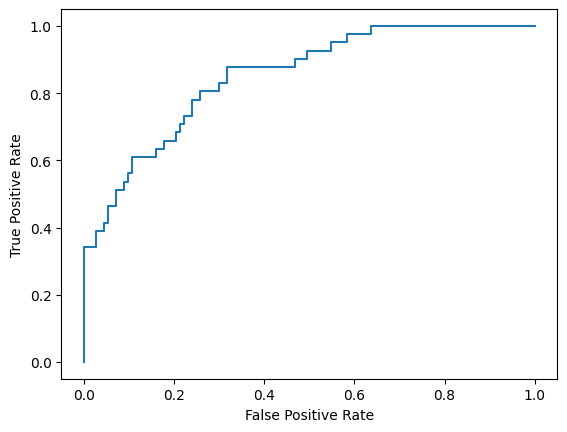

AUC = 0.8506367364558601


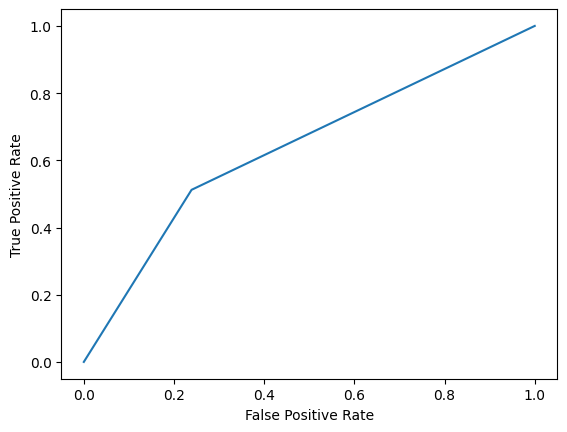

AUC = 0.6366285344269371


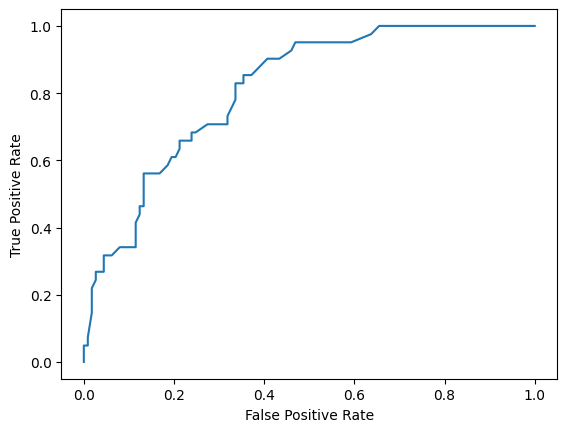

AUC = 0.8129721562702352


In [31]:
plot_roc(model_LR, y_proba_LR)
plot_roc(model_DT, y_proba_DT)
plot_roc(model_RF, y_proba_RF)